In [1]:
import pandas as pd
import numpy as np
import os, sys
import matplotlib.pyplot as plt


In [2]:
#rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny

path = "./data/newyorker_caption_contest/data/"
dirs = os.listdir(path)
files = [os.path.join(path,i) for i in os.listdir(path) if os.path.isfile(os.path.join(path,i))]


df = pd.DataFrame()

data_frames = []
for file in files:
    
    data = pd.read_csv(file, sep=',')
    data['contest_id'] = os.path.split(file)[-1]
    data_frames.append(data)

df = pd.concat(data_frames, ignore_index=True)
    
        

df['contest_id'] = df['contest_id'].str.replace('.csv', '')  # Remove '.csv' from values
df['contest_id'] = df['contest_id'].astype(int)  # Remove '.csv' from values


In [3]:
#df['rank'] = df['rank'].astype(int)

df.to_csv("./data/combined_captions.csv", index=True)
df.info()
df.head(100)
#df.tail()
df


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2292678 entries, 0 to 2292677
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   rank            float64
 1   caption         object 
 2   mean            float64
 3   precision       float64
 4   votes           int64  
 5   not_funny       int64  
 6   somewhat_funny  int64  
 7   funny           int64  
 8   contest_id      int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 157.4+ MB


,rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny,contest_id
0,0.0,I'm a congressman--obstruction is my job.,1.913043,0.094022,69,24,27,18,510
1,1.0,"I'm what they mean when they say, 'The middle ...",1.842105,0.191381,19,8,6,5,510
2,2.0,Does this suit make me look flat?,1.711111,0.112915,45,21,16,8,510
3,3.0,"When the right woman comes along, I'll know it.",1.625000,0.116657,32,15,14,3,510
4,4.0,"I used to lie in the gutter, but then I quit d...",1.617647,0.133610,34,19,9,6,510
...,...,...,...,...,...,...,...,...,...
2292673,NaN,Looks like we took a wrong turn at the Hubble ...,1.023256,0.016347,86,84,2,0,895
2292674,NaN,Post-modern just doesn't do it for me.,1.022222,0.015625,90,88,2,0,895
2292675,NaN,How was I supposed to know they covered themse...,1.020833,0.014654,96,94,2,0,895
2292676,NaN,"No, they wanted us to teleport the giveaway ca...",1.020619,0.020619,97,96,0,1,895


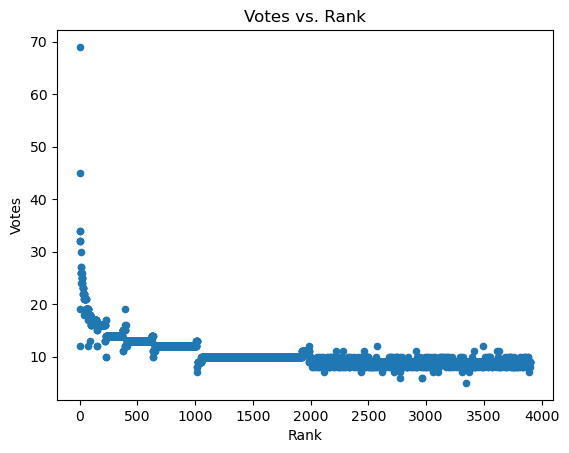

In [4]:
# Assuming 'df' is your DataFrame
df_filtered = df[df['contest_id'] == 510]

# Creating the scatter plot
df_filtered.plot(kind='scatter', x='rank', y='votes', title='Votes vs. Rank', xlabel='Rank', ylabel='Votes')

# Show the plot
plt.show()

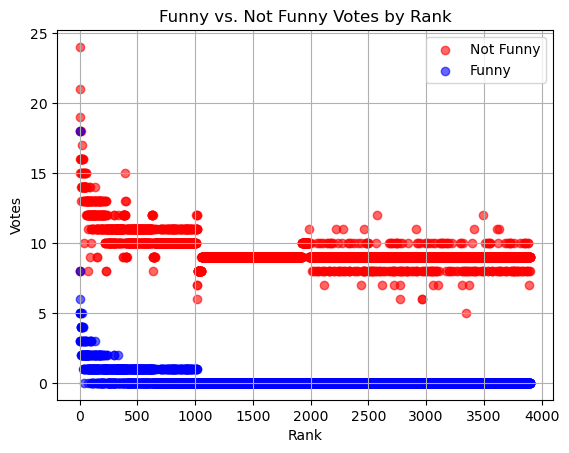

In [5]:
# Scatter plot for "not funny" votes
plt.scatter(df_filtered['rank'], df_filtered['not_funny'], color='red', label='Not Funny', alpha=0.6)

# Scatter plot for "funny" votes
plt.scatter(df_filtered['rank'], df_filtered['funny'], color='blue', label='Funny', alpha=0.6)


# Adding titles and labels
plt.title('Funny vs. Not Funny Votes by Rank')
plt.xlabel('Rank')
plt.ylabel('Votes')
plt.legend()  # Show legend
plt.grid(True)  # Optional: Adding grid for better readability
plt.show()

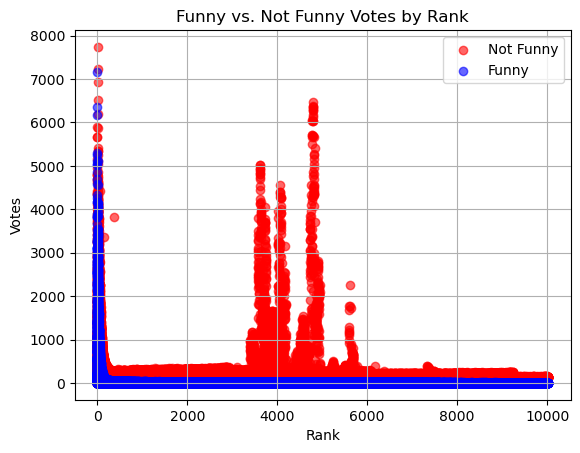

C:\Users\idont\AppData\Local\Temp\ipykernel_34088\2749195440.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_without_rank['rank'] = np.arange(0, len(df_without_rank))


<class 'pandas.core.frame.DataFrame'>
Index: 1456123 entries, 836555 to 2292677
Data columns (total 9 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   rank            1456123 non-null  int64  
 1   caption         1456071 non-null  object 
 2   mean            1456123 non-null  float64
 3   precision       1456123 non-null  float64
 4   votes           1456123 non-null  int64  
 5   not_funny       1456123 non-null  int64  
 6   somewhat_funny  1456123 non-null  int64  
 7   funny           1456123 non-null  int64  
 8   contest_id      1456123 non-null  int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 111.1+ MB


c:\Users\idont\anaconda3\envs\ada\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\idont\anaconda3\envs\ada\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


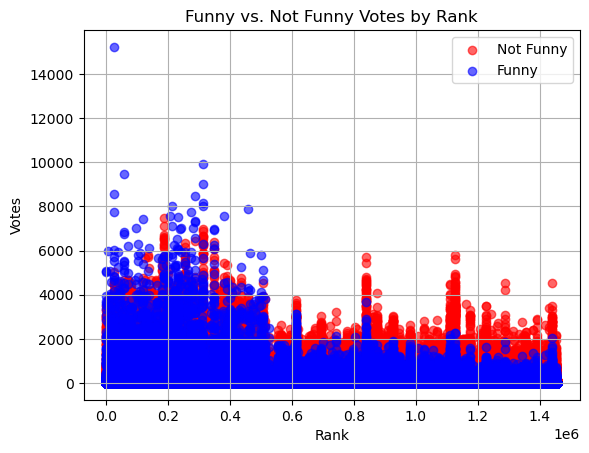

In [6]:
# prove that the missing ranks in the datasets from 660 onwards are actually still just ranks 

df_with_rank = df[df['rank'].notnull()]

# Scatter plot for "not funny" votes
plt.scatter(df_with_rank['rank'], df_with_rank['not_funny'], color='red', label='Not Funny', alpha=0.6)

# Scatter plot for "funny" votes
plt.scatter(df_with_rank['rank'], df_with_rank['funny'], color='blue', label='Funny', alpha=0.6)

# Adding titles and labels
plt.title('Funny vs. Not Funny Votes by Rank')
plt.xlabel('Rank')
plt.ylabel('Votes')
plt.legend()  # Show legend
plt.grid(True)  # Optional: Adding grid for better readability
plt.show()

df_without_rank = df[df['rank'].isnull()]
# index is rank
df_without_rank['rank'] = np.arange(0, len(df_without_rank))
df_without_rank.info()


# Scatter plot for "not funny" votes
plt.scatter(df_without_rank['rank'], df_without_rank['not_funny'], color='red', label='Not Funny', alpha=0.6)

# Scatter plot for "funny" votes
plt.scatter(df_without_rank['rank'], df_without_rank['funny'], color='blue', label='Funny', alpha=0.6)

# Adding titles and labels
plt.title('Funny vs. Not Funny Votes by Rank')
plt.xlabel('Rank')
plt.ylabel('Votes')
plt.legend()  # Show legend
plt.grid(True)  # Optional: Adding grid for better readability
#plt.show()


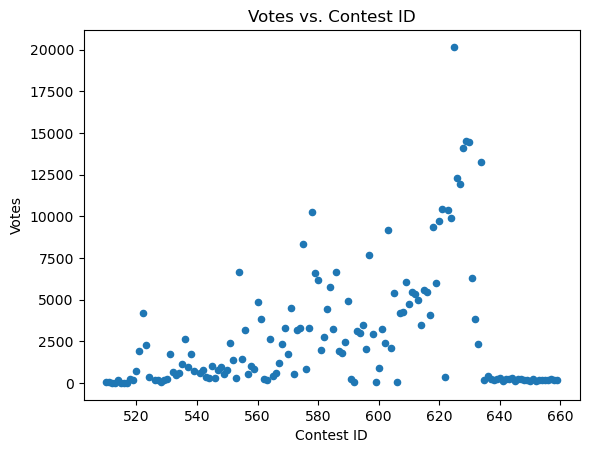

In [7]:
# Creating the scatter plot

df_max = df[df['rank'] == 0]


df_max.plot(kind='scatter', x='contest_id', y='votes', title='Votes vs. Contest ID', xlabel='Contest ID', ylabel='Votes')

# Show the plot
plt.show()

baseball.index.is_unique

baseball_newind.query('ab > 500')

min_ab = 500
baseball_newind.query('ab > @min_ab')

len(baseball[baseball.team.isin(['LAN', 'SFN'])])

use hierarchical indexing for contests
i can give name to index levels

i can use sorting

baseball[['player','sb','cs']].sort_values(ascending=[False,True], 
                                           by=['sb', 'cs']).head(10)


foo.dropna()

data summarization

baseball.describe()

cdystonia_grouped = cdystonia.groupby(cdystonia.patient)

for patient, group in cdystonia_grouped:
    print('patient', patient)
    print('group', group)

In [8]:
df.describe()

,rank,mean,precision,votes,not_funny,somewhat_funny,funny,contest_id
count,836555.000000,2.292678e+06,2.292678e+06,2.292678e+06,2.292678e+06,2.292678e+06,2.292678e+06,2.292678e+06
mean,3022.435883,1.212950e+00,inf,1.269750e+02,9.192197e+01,2.492293e+01,1.012452e+01,7.064690e+02
std,1964.559533,1.223762e-01,NaN,3.522038e+02,1.548743e+02,1.217136e+02,9.112131e+01,1.060103e+02
min,0.000000,8.571429e-01,1.546432e-04,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.100000e+02
25%,1413.000000,1.133333e+00,4.101020e-02,6.000000e+01,5.100000e+01,6.000000e+00,1.000000e+00,6.170000e+02
50%,2826.000000,1.200000e+00,4.834570e-02,8.400000e+01,6.900000e+01,1.200000e+01,2.000000e+00,7.140000e+02
75%,4340.000000,1.275676e+00,5.653322e-02,1.230000e+02,9.700000e+01,2.100000e+01,6.000000e+00,7.910000e+02
max,10024.000000,2.998918e+00,inf,2.589100e+04,7.740000e+03,9.721000e+03,1.523200e+04,8.950000e+02


In [9]:
# find not complete parts   e.g 63867

# identify the empty cells, count them 
#df.dropna()

# if the votes cell is empty, drop the line
df_cleaned = df.dropna(subset=['votes'])
df_cleaned.to_csv("./data/test.csv", index=True)


# delete the datapoint if some cells are empty of the empty cells 
# we can make rank to empty, we don't need it for our analysis 

In [11]:
# Set display options for pandas
pd.set_option('display.max_colwidth', None)  # or use a specific integer to limit the width

df.iloc[[63867, 63872, 63873]]

,rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny,contest_id
63867,485.0,I don’t think we missed out on anything not having kids.,1.388889,0.055173,126,86,31,9,523
63872,490.0,"So....what type of business did you say you were in?\r\n65,25,11,Well at least they're not on our backs any more.\r\n49,11,5,Planet of the Apes in 3D is a little too intense for me.\r\n49,15,4,The bonus features on this new Planet Of The Apes BluRay might be a bit too much.\r\n35,3,1,One of these monkeys must have some Shakespeare in him.\r\n51,16,4,What else do we need besides bananas?\r\n42,5,3,I told you not to vote for Trump.\r\n36,6,0,I've been hanging with you for a long time Doris and I still can't figure out what you want.\r\n37,8,1,I told you they were probably delivered in a barrel for a very good reason.\r\n51,5,4,You just had to go to Costco and get a whole barrel.\r\n44,12,3,Could it be that Nigerian email that we replied to?\r\n43,6,3,Does this mean we can't have sex?\r\n40,8,1,Anything would be more fun than this.\r\n31,3,0,WHAT CAN I SAY IT'S A MAN THING""",1.388235,0.069197,85,59,19,7,523
63873,491.0,They share 98% of your DNA too.,1.388235,0.073133,85,61,15,9,523
